## Install Libraries

In [1]:
pip install ehtim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.0/445.0 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 9.4 MB/s eta 0:00:00
  Created wheel for paramsurvey: filename=paramsurvey-0.4.21-py3-none-any.whl size=36647 sha256=83acfab497b6327d62c3554f8f0b9622de7f74833f31b52cce86fd42755f713b
  Stored in directory: /root/.cache/pip/wheels/8b/f8/99/8f3c76a241257caf637d7d481e5602c61a28076d436d63b495
  Created wheel for pandas-appender: filename=pandas_appender-0.9.9-py3-none-any.whl size=

In [2]:
import numpy as np
import ehtim as eh
import ehtim.const_def as ehc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

Welcome to eht-imaging! v 1.2.10 



## Observation Parameters

In [3]:
# =============================================================================
# SECTION 2: SOURCE & OBSERVATION PARAMETERS
# =============================================================================
print("\n" + "=" * 60)
print("SECTION 2: SOURCE & OBSERVATION PARAMETERS")
print("=" * 60)

# Sgr A* coordinates (ehtim wants RA in hours, Dec in degrees)
ra_hr = 17 + 45/60 + 40.0383/3600       # 17h 45m 40.0383s
dec_deg = -(29 + 0/60 + 28.069/3600)    # -29° 00' 28.069"

# Observation setup
rf = 86e9             # Reference frequency [Hz] (86 GHz)
bw = 8e9               # Bandwidth [Hz]: Assumed 8 GHz? worst-case scenario currently assumed
mjd = 60827.4166667    # june 1, 2025, 10 UTC

# Scheduling
tint = 10.0            # Integration time [s]
tadv = 60.0            # Cadence between samples [s] - same as duty cycle in spacevlbi
tstart = 0.0           # Start time [hr UTC]
tstop = 24.0           # Stop time [hr UTC]
elevmin = 15.0         # Minimum elevation for ground stations [deg]
# optimize these parameters later so we can constrain necess

# Imaging grid
npix = 128
fov = 200.0 * ehc.RADPERUAS # default value taken from EHT, but fov should not impact (u, v)

print(f"\nSource: Sgr A*")
print(f"  Right Ascension:          {ra_hr:.6f} hr ({int(ra_hr)}h {int((ra_hr%1)*60)}m {((ra_hr*60)%1)*60:.2f}s)")
print(f"  Declination:              {dec_deg:.6f}°")
print(f"\nObservation Setup:")
print(f"  Frequency:                {rf/1e9:.0f} GHz (λ = {3e8/rf*1e3:.2f} mm)")
print(f"  Bandwidth:                {bw/1e9:.1f} GHz")
print(f"  MJD:                      {mjd}")
print(f"  Observation window:       {tstart:.1f} - {tstop:.1f} hr UTC ({tstop-tstart:.0f} hours)")
print(f"  Integration time:         {tint:.0f} s")
print(f"  Sample cadence:           {tadv:.0f} s")
print(f"  Min elevation (ground):   {elevmin}°")


SECTION 2: SOURCE & OBSERVATION PARAMETERS

Source: Sgr A*
  Right Ascension:          17.761122 hr (17h 45m 40.04s)
  Declination:              -29.007797°

Observation Setup:
  Frequency:                86 GHz (λ = 3.49 mm)
  Bandwidth:                8.0 GHz
  MJD:                      60827.4166667
  Observation window:       0.0 - 24.0 hr UTC (24 hours)
  Integration time:         10 s
  Sample cadence:           60 s
  Min elevation (ground):   15.0°


## Ground Truth Model

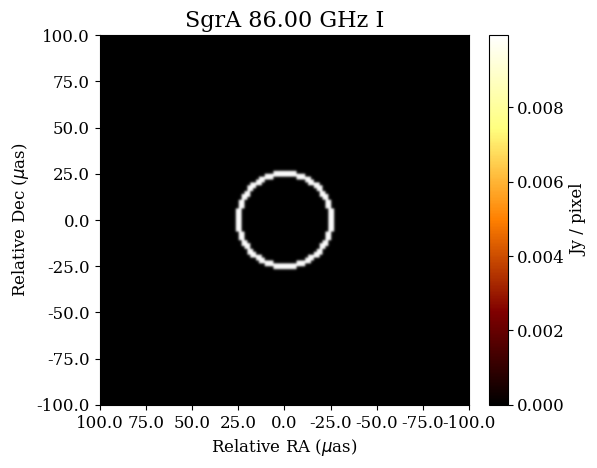

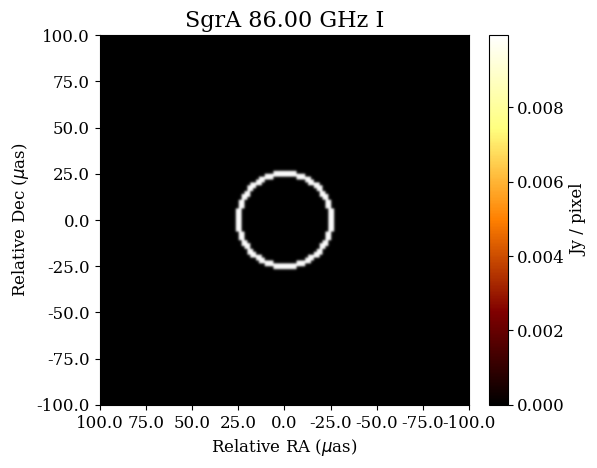

In [4]:
# =============================================================================
# TRUTH MODEL: THIN RING, 50 μas DIAMETER
# =============================================================================
total_flux = 2.0
ring_diam_uas = 50.0
ring_diam_rad = ring_diam_uas * ehc.RADPERUAS

mod = eh.model.Model(ra_hr, dec_deg, rf=rf, source="SgrA", mjd=mjd)
mod = mod.add_ring(F0=total_flux, d=ring_diam_rad, x0=0.0, y0=0.0)  # d is diameter (radians) :contentReference[oaicite:2]{index=2}

truth_img = mod.make_image(fov, npix)

truth_img.display()

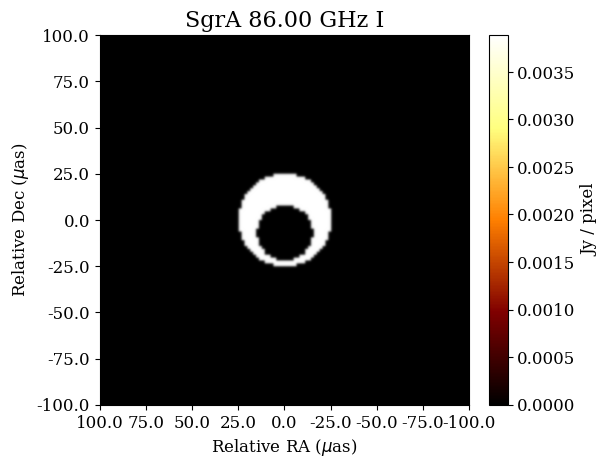

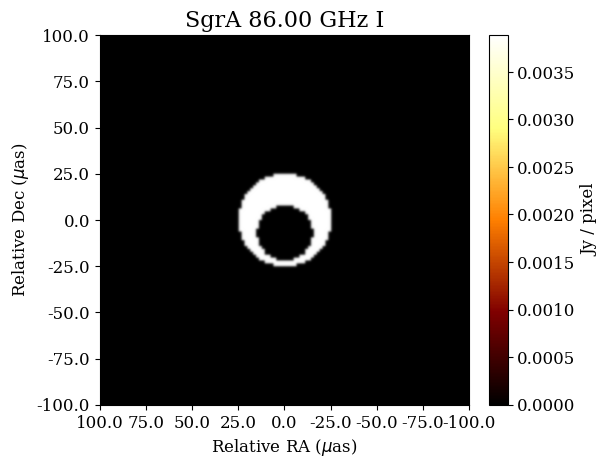

In [5]:
mod = eh.model.Model(ra_hr, dec_deg, rf=rf, source="SgrA", mjd=mjd)
mod = mod.add_crescent(F0=2.0,
                       d=ring_diam_rad,
                       fr=0.6,
                       fo=0.7,
                       ff=0,
                       phi=np.deg2rad(180),
                       x0=0.0,
                       y0=0.0,
                       pol_frac=0.0,
                       pol_evpa=0.0,
                       cpol_frac=0.0)


newTruth = mod.make_image(fov, npix)
newTruth.display()

## Space Observing Array

In [6]:
# =============================================================================
# SECTION 1: ORBITAL CONFIGURATION
# =============================================================================
print("=" * 60)
print("SECTION 1: ORBITAL CONFIGURATION")
print("=" * 60)

# Earth constants
Re = 6378.137e3          # Earth radius [m]
mu = 3.986004418e14      # Gravitational parameter [m³/s²]

# LEO satellite altitudes [km] - triangular constellation
altitudes_km = [600, 620, 640]
sat_names = ["SAT1", "SAT2", "SAT3"]

# Common orbital elements
inc_deg = 85.0           # Inclination [deg] - high inclination for polar coverage
ecc = 0.0                # Eccentricity (circular orbits)
argp_deg = 0.0           # Argument of perigee [deg]

# RAAN spacing: 120° apart for triangular ground track pattern
raan_base_deg = 110.0
raan_offsets = [0.0, 120.0, 240.0]

# Compute orbital parameters for each satellite
print(f"\n{'Satellite':<10} {'Altitude':>10} {'Semi-major':>12} {'Period':>10} {'RAAN':>8}")
print(f"{'':10} {'(km)':>10} {'axis (km)':>12} {'(min)':>10} {'(deg)':>8}")
print("-" * 60)

orbital_params = []
for i, (sat, alt_km) in enumerate(zip(sat_names, altitudes_km)):
    a = (alt_km * 1e3) + Re                    # Semi-major axis [m]
    n_mean = np.sqrt(mu / a**3)                # Mean motion [rad/s]
    period_s = 2 * np.pi / n_mean              # Period [s]
    period_min = period_s / 60.0               # Period [min]
    period_days = period_s / 86400.0           # Period [days]
    raan_deg = raan_base_deg + raan_offsets[i]

    orbital_params.append({
        'name': sat,
        'altitude_km': alt_km,
        'a': a,
        'period_s': period_s,
        'period_days': period_days,
        'raan_deg': raan_deg
    })

    print(f"{sat:<10} {alt_km:>10.1f} {a/1e3:>12.1f} {period_min:>10.1f} {raan_deg:>8.1f}")

print("-" * 60)
print(f"{'Common parameters:':<30}")
print(f"  Inclination:              {inc_deg}°")
print(f"  Eccentricity:             {ecc}")
print(f"  Argument of perigee:      {argp_deg}°")
print(f"  Configuration:            Triangular (RAAN spacing = 120°)")

SECTION 1: ORBITAL CONFIGURATION

Satellite    Altitude   Semi-major     Period     RAAN
                 (km)    axis (km)      (min)    (deg)
------------------------------------------------------------
SAT1            600.0       6978.1       96.7    110.0
SAT2            620.0       6998.1       97.1    230.0
SAT3            640.0       7018.1       97.5    350.0
------------------------------------------------------------
Common parameters:            
  Inclination:              85.0°
  Eccentricity:             0.0
  Argument of perigee:      0.0°
  Configuration:            Triangular (RAAN spacing = 120°)


In [7]:
# =============================================================================
# SECTION 4: ARRAY CONFIGURATION
# =============================================================================
print("\n" + "=" * 60)
print("SECTION 4: ARRAY CONFIGURATION")
print("=" * 60)

# ALMA position in Earth-centered coordinates (normalized to Earth radius)
alma_ecef_normalized = (0.34925, -0.85388, -0.38953)
alma_coords_m = Re * np.array(alma_ecef_normalized)

# SEFDs (System Equivalent Flux Density) - lower = more sensitive
alma_sefd = 100.0      # ALMA is very sensitive
sat_sefd = 60000.0     # Small space antennas are less sensitive

# Initialize empty array
arr = eh.array.Array(np.array([], dtype=ehc.DTARR))

# Add ALMA
arr = arr.add_site("ALMA", coords=alma_coords_m, sefd=alma_sefd)
print(f"\nGround Stations:")
print(f"  ALMA                      SEFD = {alma_sefd:.0f} Jy")

# Add satellites
print(f"\nSpace Segment:")
for i, params in enumerate(orbital_params):
    # Phase the satellites in their orbits (spread by 1/3 of period)
    perigee_offset_days = i * params['period_days'] / 3.0

    arr = arr.add_satellite_elements(
        params['name'],
        perigee_mjd=mjd + tstart/24.0 + perigee_offset_days,
        period_days=params['period_days'],
        eccentricity=ecc,
        inclination=inc_deg,
        arg_perigee=argp_deg,
        long_ascending=params['raan_deg'],
        sefd=sat_sefd
    )
    print(f"  {params['name']}                     SEFD = {sat_sefd:.0f} Jy, alt = {params['altitude_km']:.0f} km")

print(f"\nTotal stations:             {len(arr.tarr)} (1 ground + 3 space)")

# Count baselines
n_stations = len(arr.tarr)
n_baselines = n_stations * (n_stations - 1) // 2
print(f"Number of baselines:        {n_baselines}")
print(f"  Ground-Space:             3 (ALMA-SAT1, ALMA-SAT2, ALMA-SAT3)")
print(f"  Space-Space:              3 (SAT1-SAT2, SAT1-SAT3, SAT2-SAT3)")


SECTION 4: ARRAY CONFIGURATION

Ground Stations:
  ALMA                      SEFD = 100 Jy

Space Segment:
  SAT1                     SEFD = 60000 Jy, alt = 600 km
  SAT2                     SEFD = 60000 Jy, alt = 620 km
  SAT3                     SEFD = 60000 Jy, alt = 640 km

Total stations:             4 (1 ground + 3 space)
Number of baselines:        6
  Ground-Space:             3 (ALMA-SAT1, ALMA-SAT2, ALMA-SAT3)
  Space-Space:              3 (SAT1-SAT2, SAT1-SAT3, SAT2-SAT3)


## $(u,v)$ Coverage


SECTION 5: GENERATE (u,v) COVERAGE
Adding gain + phase errors to data and applying a priori calibration . . . 
Adding thermal noise to data . . . 


/usr/local/lib/python3.12/dist-packages/ehtim/observing/obs_helpers.py:1067: RuntimeWarning: invalid value encountered in scalar divide
  anglebtw = np.array([np.dot(obsvec, sourcevec)/np.linalg.norm(obsvec) /



UV sampling generated:
  Total visibility points:  3427


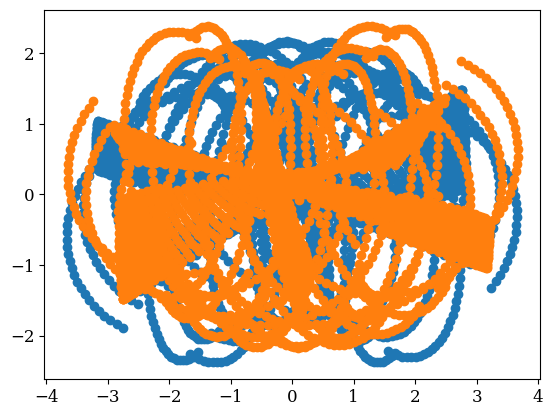

In [8]:
# =============================================================================
# SECTION 5: GENERATE (u,v) COVERAGE
# =============================================================================
print("\n" + "=" * 60)
print("SECTION 5: GENERATE (u,v) COVERAGE")
print("=" * 60)

# Generate observation with uv sampling (no visibilities yet)
obs0 = arr.obsdata(
    ra_hr, dec_deg, rf, bw,
    tint=tint, tadv=tadv, tstart=tstart, tstop=tstop,
    mjd=mjd, timetype='UTC', polrep='stokes',
    elevmin=elevmin, no_elevcut_space=True
)

obs = mod.observe_same(
    obs0,
    add_th_noise=True,     # Add thermal noise based on SEFDs
    opacitycal=True,       # Assume perfect opacity calibration
    ampcal=True,           # Assume perfect amplitude calibration
    phasecal=True          # Assume perfect phase calibration
)

print(f"\nUV sampling generated:")
print(f"  Total visibility points:  {len(obs0.data)}")

t1, t2 = obs.data['t1'], obs.data['t2']
u, v = obs.data['u'] / 1e9, obs.data['v'] / 1e9

plt.scatter(u, v)
plt.scatter(-u, -v)

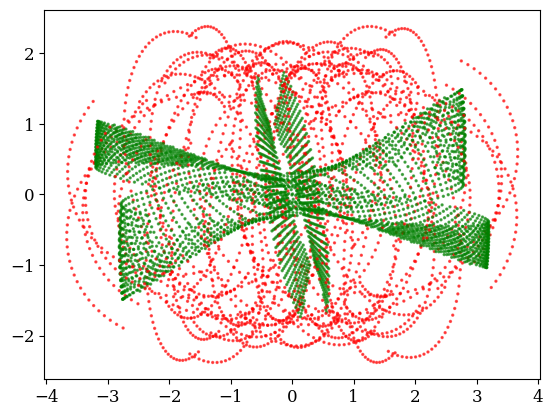

In [9]:
# Color-code by baseline type
colors = []
for s1, s2 in zip(t1, t2):
    if 'SAT' in s1 and 'SAT' in s2:
        colors.append('green')       # Space-Space
    elif 'SAT' in s1 or 'SAT' in s2:
        colors.append('red')         # Ground-Space
    else:
        colors.append('blue')        # Ground-Ground

plt.scatter(u, v, c=colors, s=2, alpha=0.6)
plt.scatter(-u, -v, c=colors, s=2, alpha=0.6)  # Conjugate points